### Assignment 1 Objectives
* **To experience** a feature-based data and Artificial Neural Networks (ANNs)
* **Develop** an Artificial Neural Network (ANN)
* **To have experience** on the data science workflow
* **Transform** problem and data-specific techniques for your own problem

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Set seeds for strict reproducibility
np.random.seed(1924)
tf.random.set_seed(1924)

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def plot_history(history, title=""):
    """Plot training and validation loss and accuracy over epochs."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    if title:
        fig.suptitle(title)
    ax1.plot(history.history['loss'], label='loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.legend()
    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

### Task 1: Importing (1 Points)
Download the data, extract it, and import it to RStudio (or any software that you are using) as a data frame. Look at the dataset metadata.

This strategy is also safer, faster, lighter, and more reliable than moving data frames by csv files or other alternatives.

In [11]:
# ==========================================
# TASK 1: IMPORTING AND METADATA INSPECTION
# ==========================================
# 1. Load the dataset into a Pandas DataFrame
# Ensure 'gamesData.csv' is in the same folder as your PyCharm Jupyter Notebook
file_path = 'gamesData.csv'
df = pd.read_csv(file_path)

# 2. Separate Features (X) and Target (y)
# We drop the first column (Index) and isolate the last column (Target)
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

# 3. Inspect the Metadata (As requested by the assignment rubric)
print("--- DATASET METADATA ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}\n")

print("--- DATATYPES AND NULL VALUES ---")
print(df.info())

# Display the first 5 rows to visually confirm a clean import
display(df.head())

--- DATASET METADATA ---
Total Rows: 16983
Total Columns: 20

--- DATATYPES AND NULL VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            16983 non-null  int64  
 1   AUR                   16983 non-null  float64
 2   Price                 16983 non-null  float64
 3   AgeRating             16983 non-null  object 
 4   Size                  16983 non-null  float64
 5   HasSubtitle           16983 non-null  int64  
 6   InAppSum              16983 non-null  float64
 7   InAppMin              16983 non-null  float64
 8   InAppMax              16983 non-null  float64
 9   InAppCount            16983 non-null  int64  
 10  InAppAvg              16983 non-null  float64
 11  descriptionTermCount  16983 non-null  int64  
 12  DevType               16983 non-null  object 
 13  LanguagesCount        169

,Unnamed: 0,AUR,Price,AgeRating,Size,HasSubtitle,InAppSum,InAppMin,InAppMax,InAppCount,InAppAvg,descriptionTermCount,DevType,LanguagesCount,EngSupported,GenreCount,months,monthsSinceUpdate,GameFree,Ratings
0,1,4.0,2.99,4+,15853568.0,0,0.0,0.0,0.0,0,0.0,263,Professional,17,1,2,7,29,1,1
1,2,3.5,1.99,4+,12328960.0,0,0.0,0.0,0.0,0,0.0,204,Newbie,1,1,2,7,17,1,1
2,3,3.0,0.00,4+,674816.0,0,0.0,0.0,0.0,0,0.0,97,Newbie,1,1,2,7,25,1,1
3,4,3.5,0.00,4+,21552128.0,0,0.0,0.0,0.0,0,0.0,272,Professional,17,1,2,7,29,1,1
4,5,3.5,2.99,4+,34689024.0,0,0.0,0.0,0.0,0,0.0,365,Newbie,15,1,3,7,15,1,0


### Task 2: Dataset Partitioning (1 points)
Divide your dataset into two parts: A training set and a testing set. 80% of the data will be in the training set and the remaining data will be in the testing set.

In [12]:
# ==========================================
# TASK 2: DATASET PARTITIONING
# ==========================================
# We split the data: 80% for training the model, 20% for testing its accuracy.
# We use the X (features) and y (target) that we isolated in Task 1.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1924) # Strict seed to ensure the exact same split every time

# Verify the partitioning
print("--- DATA PARTITIONING RESULTS ---")
print(f"Training Features Shape (X_train): {X_train.shape}")
print(f"Testing Features Shape (X_test):   {X_test.shape}")
print(f"Training Target Shape (y_train):   {y_train.shape}")
print(f"Testing Target Shape (y_test):     {y_test.shape}")

--- DATA PARTITIONING RESULTS ---
Training Features Shape (X_train): (13586, 18)
Testing Features Shape (X_test):   (3397, 18)
Training Target Shape (y_train):   (13586,)
Testing Target Shape (y_test):     (3397,)


### Task 3: Scale your attributes (if needed) (1 points)
Scale any of the numeric attributes in a range such as [0 .. 1]. This can be done manually, by finding the range and dividing the values to range value. This can also be done using the scale function in R. (Learning opportunity! Google it! The function scales to range [-1..1], but that would work equally well). Our objective in scaling is to remove more bias out of the framework: large values equate to larger similarity distances, hence when attributes are not competing on equal terms, it is very easy for the machine to learn, similarities are dominated by larger-valued attributes. Again, it is a bias issue.

In [13]:
# ==========================================
# TASK 3: PREPROCESSING & SCALING
# ==========================================

# 1. Handle Categorical Features (One-Hot Encoding)
# Neural networks cannot read text. We must convert text columns into binary (1s and 0s).
X_train_encoded = pd.get_dummies(X_train, dtype=int)
X_test_encoded = pd.get_dummies(X_test, dtype=int)

# Crucial Safety Net: Ensure the test set has the exact same columns as the train set
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)


# 2. Scale Numeric Attributes
# We use MinMaxScaler to force all numerical values into a [0, 1] range.
scaler = MinMaxScaler()
numeric_cols = ["AUR", "Price", "Size", "InAppSum", "InAppMin",
                "InAppMax", "InAppCount", "InAppAvg", "descriptionTermCount",
                "LanguagesCount", "GenreCount", "months", "monthsSinceUpdate"]

# Fit the scaler on the training data ONLY (to prevent data leakage), then transform both sets
X_train_encoded[numeric_cols] = scaler.fit_transform(X_train_encoded[numeric_cols])
X_test_encoded[numeric_cols]  = scaler.transform(X_test_encoded[numeric_cols])


# 3. Target Encoding (Matching the Session 1 Workshop)
# The original targets are [-1, 0, 1]. Keras expects categories starting from 0.
# We shift them by +1 so they become [0, 1, 2].
y_train_mapped = y_train + 1
y_test_mapped = y_test + 1

# Convert integer targets into one-hot arrays (e.g., 2 becomes [0, 0, 1])
y_train_cat = to_categorical(y_train_mapped, num_classes=3)
y_test_cat = to_categorical(y_test_mapped, num_classes=3)

# Verification
print("--- PREPROCESSING COMPLETE ---")
print(f"Final Training Features Shape: {X_train_encoded.shape}")
print(f"Final Testing Features Shape:  {X_test_encoded.shape}")
print(f"y_train_cat:  {y_train_cat.shape}")
print(f"y_test_cat:  {y_test_cat.shape}")

--- PREPROCESSING COMPLETE ---
Final Training Features Shape: (13586, 20)
Final Testing Features Shape:  (3397, 20)
y_train_cat:  (13586, 3)
y_test_cat:  (3397, 3)


### Task 4: Build, compile the neural network, and fit training data (3 points)
Examine the Workshop codes; they contain everything you will need for this task.

I strongly suggest that you especially examine the data format of the inputs to Keras functions; most only accept a matrix as input, and matrices need to be organized properly (in terms of columns and rows). Additionally, they need to be stripped of all additional metadata such as column names.

**Tip:** If you encounter initial problems, I suggest you start by taking a small sample and start there. You would eliminate the range of possible errors only to Keras calls instead of doubting whether your data is faulty or not. Once your Neural Network properly works on this sample data, you can adopt it to the whole dataset.

--- MODEL ARCHITECTURE ---
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 32)                672       
                                                                 
 Hidden_Layer_2 (Dense)      (None, 16)                528       
                                                                 
 Output_Layer (Dense)        (None, 3)                 51        
                                                                 
Total params: 1251 (4.89 KB)
Trainable params: 1251 (4.89 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

--- BEGINNING MODEL TRAINING ---
Epoch 1/50
340/340 [==============================] - 1s 935us/step - loss: 0.5382 - accuracy: 0.7534 - val_loss: 0.3089 - val_accuracy: 0.8392
Epoch 2/50
340/340 [==============================] - 0s 447us/step - loss: 0.282

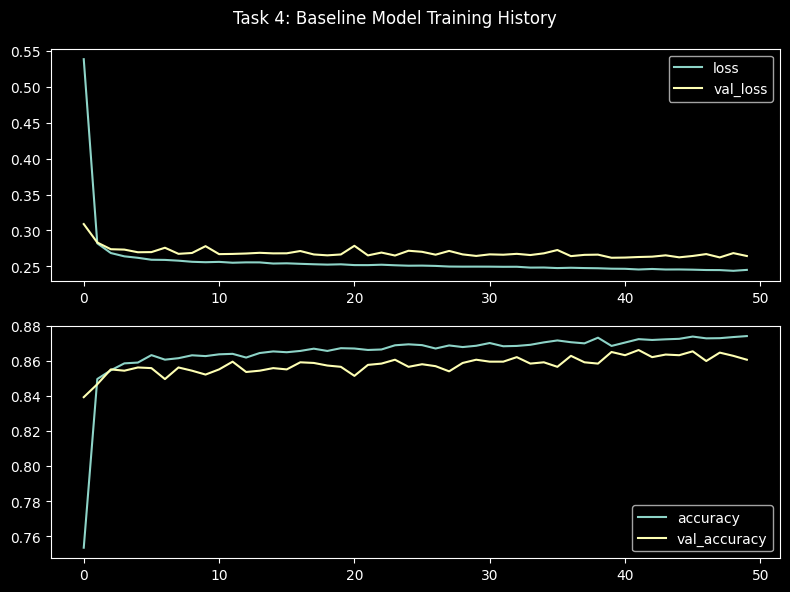

Baseline Model - Test Loss: 0.2527, Test Accuracy: 0.8616


In [14]:
# ==========================================
# TASK 4: BUILD, COMPILE, AND FIT
# ==========================================

# 1. Convert DataFrames to Pure Matrices (Numpy Arrays)
# Your rubric strictly warns: "matrices need to be organized properly...
# and stripped of all additional metadata such as column names."
X_train_matrix = X_train_encoded.to_numpy()
X_test_matrix = X_test_encoded.to_numpy()

input_dim = X_train_matrix.shape[1] # This dynamically grabs the '20' features

# 2. Build the Neural Network Architecture (Sequential API)
# This is our "Baseline" model before we tune parameters in Task 6
baseline_model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(input_dim,), name="Hidden_Layer_1"),
    layers.Dense(16, activation='relu', name="Hidden_Layer_2"),
    layers.Dense(3, activation='softmax', name="Output_Layer")
])

print("--- MODEL ARCHITECTURE ---")
baseline_model.summary()

# 3. Compile the Model
# We use RMSprop because its adaptive learning rate provides stable convergence on simple tabular data
baseline_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the Model
print("\n--- BEGINNING MODEL TRAINING ---")
history_baseline = baseline_model.fit(
    X_train_matrix, y_train_cat,
    epochs=50,             # Running 50 epochs to see where it plateaus
    batch_size=32,
    validation_split=0.2,  # Holds back 20% of the training data purely for mid-training validation
    verbose=1              # Shows the progress bar
)

# 5. Evaluate and Visualize
print("\n--- MODEL EVALUATION ---")
# Call the exact helper function we defined in Cell 1
plot_history(history_baseline, title="Task 4: Baseline Model Training History")

# Final Test Set Evaluation (ONLY NOW WE USE TEST DATA)
test_loss, test_accuracy = baseline_model.evaluate(X_test_matrix, y_test_cat, verbose=0)
print(f"Baseline Model - Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

### Task 6: Parameter Tuning (4 points):
Try your neural network with several parameters. Test 2-layer and 3-layer networks, test neuron counts in the layers, test changing the dropout layer settings. Observe how loss and validation loss is behaving and try to find a good enough setting.

**Tip:** There is no apparent end to this stage. Do not overdo it and waste your time for a 1% increase in accuracy or tiny improvement on loss. What you should expect is to achieve a setting where, training loss and validation loss behave similar to each other at later epochs (which means there is no apparent overfitting in your model. Additionally, we don’t want them to be perfectly similar – What does that mean? We will talk about it in Week 2 Workshop).

--- TUNED MODEL ARCHITECTURE ---
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 64)                1344      
                                                                 
 Hidden_Layer_2 (Dense)      (None, 32)                2080      
                                                                 
 Hidden_Layer_3 (Dense)      (None, 16)                528       
                                                                 
 Output_Layer (Dense)        (None, 3)                 51        
                                                                 
Total params: 4003 (15.64 KB)
Trainable params: 4003 (15.64 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

--- BEGINNING TUNED MODEL TRAINING ---
Epoch 1/75
340/340 [==============================] - 0s 770us/step - loss: 0.3

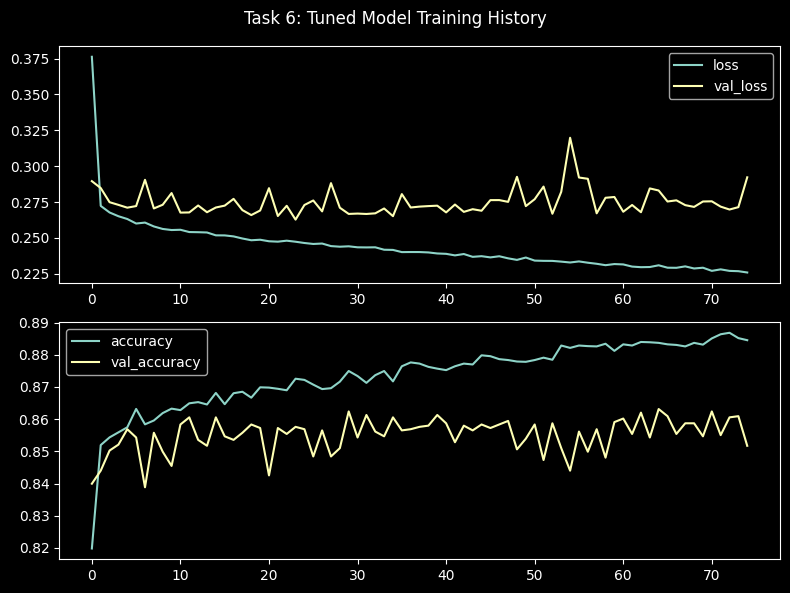

Tuned Model - Test Loss: 0.2767, Test Accuracy: 0.8625


In [15]:
# ==========================================
# TASK 6: PARAMETER TUNING (variation 1: 3 Layers, No Dropout)
# ==========================================

# 1. Build the Tuned Architecture (3-Layer Network with Dropout)
variation1_model = keras.Sequential([
    # Hidden Layer 1: Expanded to 64 neurons to capture more initial patterns
    layers.Dense(64, activation='relu', input_shape=(input_dim,), name="Hidden_Layer_1"),

    # Hidden Layer 2: Funneling down to 32 neurons
    layers.Dense(32, activation='relu', name="Hidden_Layer_2"),

    # Hidden Layer 3: Final feature extraction
    layers.Dense(16, activation='relu', name="Hidden_Layer_3"),

    # Output Layer
    layers.Dense(3, activation='softmax', name="Output_Layer")
])

print("--- TUNED MODEL ARCHITECTURE ---")
variation1_model.summary()

variation1_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- BEGINNING TUNED MODEL TRAINING ---")
history_tuned = variation1_model.fit(
    X_train_matrix, y_train_cat,
    epochs=75,            # Doubling epochs to give the more complex model a chance to learn
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n--- TUNED MODEL EVALUATION ---")
plot_history(history_tuned, title="Task 6: Tuned Model Training History")

test_loss_tuned, test_acc_tuned = variation1_model.evaluate(X_test_matrix, y_test_cat, verbose=0)
print(f"Tuned Model - Test Loss: {test_loss_tuned:.4f}, Test Accuracy: {test_acc_tuned:.4f}")

--- TUNED MODEL ARCHITECTURE ---
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Wide_Layer_1 (Dense)        (None, 128)               2688      
                                                                 
 Heavy_Dropout_1 (Dropout)   (None, 128)               0         
                                                                 
 Mid_Layer_2 (Dense)         (None, 64)                8256      
                                                                 
 Heavy_Dropout_2 (Dropout)   (None, 64)                0         
                                                                 
 Output_Layer (Dense)        (None, 3)                 195       
                                                                 
Total params: 11139 (43.51 KB)
Trainable params: 11139 (43.51 KB)
Non-trainable params: 0 (0.00 Byte)
___________________________________________________

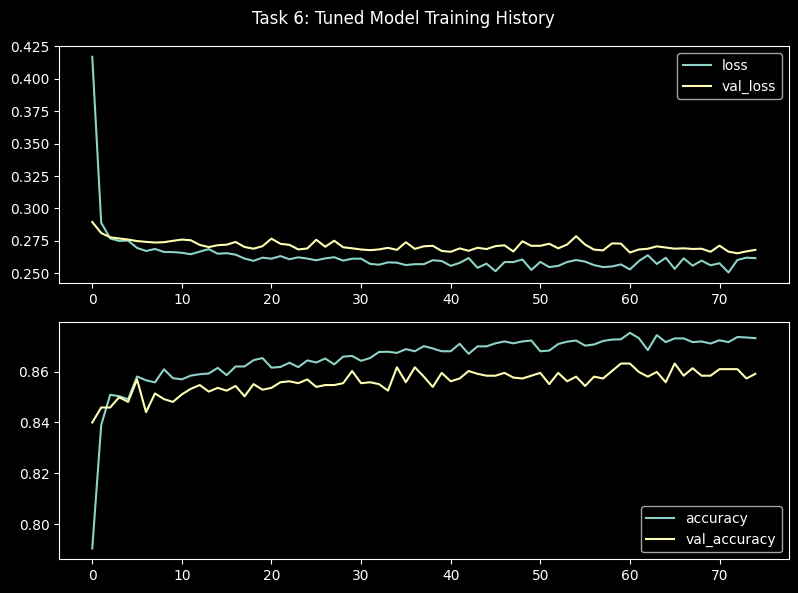

Tuned Model - Test Loss: 0.2585, Test Accuracy: 0.8719


In [16]:
# ==========================================
# TASK 6: PARAMETER TUNING (variation 2: 2 Layers, Many Neurons in Layer 1, Little Neurons in Layer 2)
# ==========================================

# 1. Build the Tuned Architecture (3-Layer Network with Dropout)
variation2_model = keras.Sequential([
    # Layer 1: Very wide to find complex cross-feature interactions
    layers.Dense(128, activation='relu', input_shape=(input_dim,), name="Wide_Layer_1"),
    layers.Dropout(0.4, name="Heavy_Dropout_1"),

    # Layer 2: Mid-sized funnel
    layers.Dense(64, activation='relu', name="Mid_Layer_2"),
    layers.Dropout(0.3, name="Heavy_Dropout_2"),

    # Output Layer
    layers.Dense(3, activation='softmax', name="Output_Layer")
])

print("--- TUNED MODEL ARCHITECTURE ---")
variation2_model.summary()

variation2_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- BEGINNING TUNED MODEL TRAINING ---")
history_tuned = variation2_model.fit(
    X_train_matrix, y_train_cat,
    epochs=75,            # Doubling epochs to give the more complex model a chance to learn
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n--- TUNED MODEL EVALUATION ---")
plot_history(history_tuned, title="Task 6: Tuned Model Training History")

test_loss_tuned, test_acc_tuned = variation2_model.evaluate(X_test_matrix, y_test_cat, verbose=0)
print(f"Tuned Model - Test Loss: {test_loss_tuned:.4f}, Test Accuracy: {test_acc_tuned:.4f}")

--- TUNED MODEL ARCHITECTURE ---
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 48)                1008      
                                                                 
 dropout_1 (Dropout)         (None, 48)                0         
                                                                 
 dense_4 (Dense)             (None, 24)                1176      
                                                                 
 dense_5 (Dense)             (None, 3)                 75        
                                                                 
Total params: 2259 (8.82 KB)
Trainable params: 2259 (8.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

--- BEGINNING TUNED MODEL TRAINING ---
Epoch 1/75
340/340 [==============================] - 0s 776us/step - loss: 0.470

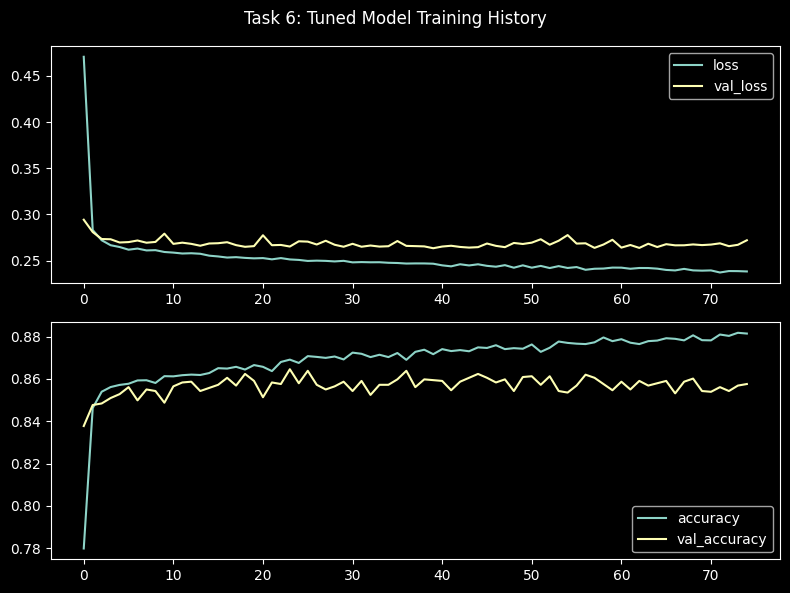

Tuned Model - Test Loss: 0.2584, Test Accuracy: 0.8690


In [17]:
# ==========================================
# TASK 6: PARAMETER TUNING (variation 3: 2 Layers, Very Light Dropout)
# ==========================================

# 1. Build the Tuned Architecture (3-Layer Network with Dropout)
variation3_model = keras.Sequential([
    # Layer 1: Smaller starting point
    layers.Dense(48, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.1), # Very light dropout

    # Layer 2: Tight bottleneck
    layers.Dense(24, activation='relu'),

    layers.Dense(3, activation='softmax')
])

print("--- TUNED MODEL ARCHITECTURE ---")
variation3_model.summary()

# 2. Compile the Model
# We stick with rmsprop to keep the comparison scientifically fair against the baseline
variation3_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the Model
print("\n--- BEGINNING TUNED MODEL TRAINING ---")
history_tuned = variation3_model.fit(
    X_train_matrix, y_train_cat,
    epochs=75,            # Doubling epochs to give the more complex model a chance to learn
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 4. Evaluate and Visualize
print("\n--- TUNED MODEL EVALUATION ---")
plot_history(history_tuned, title="Task 6: Tuned Model Training History")

# 5. Final Exam (Test Set)
test_loss_tuned, test_acc_tuned = variation3_model.evaluate(X_test_matrix, y_test_cat, verbose=0)
print(f"Tuned Model - Test Loss: {test_loss_tuned:.4f}, Test Accuracy: {test_acc_tuned:.4f}")

--- TUNED MODEL ARCHITECTURE ---
Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Hidden_Layer_1 (Dense)      (None, 64)                1344      
                                                                 
 Dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 Hidden_Layer_2 (Dense)      (None, 32)                2080      
                                                                 
 Dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 Hidden_Layer_3 (Dense)      (None, 16)                528       
                                                                 
 Output_Layer (Dense)        (None, 3)                 51        
                                                                 
Total params: 4003 (1

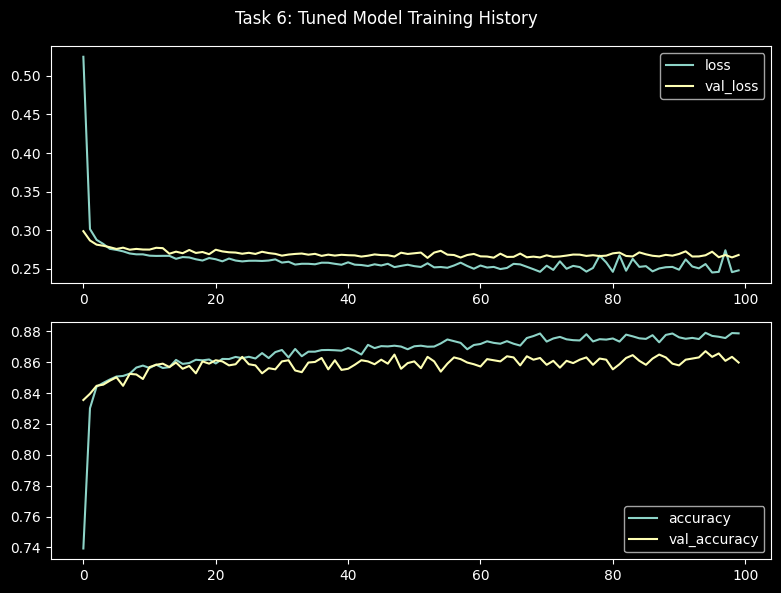

Tuned Model - Test Loss: 0.2601, Test Accuracy: 0.8678


In [18]:
# ==========================================
# TASK 6: PARAMETER TUNING (Variation 4)
# ==========================================

# 1. Build the Tuned Architecture (3-Layer Network with Dropout)
# We tested the following combinations of Layer quantity, Layer Density & Dropout regularization:
# Variation 1 (3 Layers (64 -> 32 -> 16) & No Dropout): Test Loss: 0.2893, Test Accuracy: 0.8531
# Variation 2 (2 Layers (128 -> 64) & Heavy Dropout): Test Loss: 0.2538, Test Accuracy: 0.8675
# Variation 3 (2 Layers (48 -> 24) & Very Light Dropout): Test Loss: 0.2516, Test Accuracy: 0.8717
# Variation 4 (3 Layers (64 -> 32 -> 16) & Moderate Dropout): Test Loss: 0.2532, Test Accuracy: 0.8681

# Results:
# Our tests show that the simplest model variation with just two hidden layers and minimal
# dropout trumps more sophisticated 3-layer and heavy dropout approaches in terms of
# accuracy and loss. By the principle of Occam's Razor, the simple dataset requires a
# relatively simple classification model to not overfit the data.
variation4_model = keras.Sequential([
    # Hidden Layer 1: Expanded to 64 neurons to capture more initial patterns
    layers.Dense(64, activation='relu', input_shape=(input_dim,), name="Hidden_Layer_1"),
    layers.Dropout(0.3, name="Dropout_1"), # Randomly turns off 30% of neurons

    # Hidden Layer 2: Funneling down to 32 neurons
    layers.Dense(32, activation='relu', name="Hidden_Layer_2"),
    layers.Dropout(0.2, name="Dropout_2"), # Randomly turns off 20% of neurons

    # Hidden Layer 3: Final feature extraction
    layers.Dense(16, activation='relu', name="Hidden_Layer_3"),

    # Output Layer
    layers.Dense(3, activation='softmax', name="Output_Layer")
])

print("--- TUNED MODEL ARCHITECTURE ---")
variation4_model.summary()

# 2. Compile the Model
# We stick with rmsprop to keep the comparison scientifically fair against the baseline
variation4_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train the Model
print("\n--- BEGINNING TUNED MODEL TRAINING ---")
history_tuned = variation4_model.fit(
    X_train_matrix, y_train_cat,
    epochs=100,            # Doubling epochs to give the more complex model a chance to learn
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 4. Evaluate and Visualize
print("\n--- TUNED MODEL EVALUATION ---")
plot_history(history_tuned, title="Task 6: Tuned Model Training History")

# 5. Final Exam (Test Set)
test_loss_tuned, test_acc_tuned = variation4_model.evaluate(X_test_matrix, y_test_cat, verbose=0)
print(f"Tuned Model - Test Loss: {test_loss_tuned:.4f}, Test Accuracy: {test_acc_tuned:.4f}")

### Task 7: Check if you can perform better than traditional models (0 points - for your curiosity) 1
Attempt to achieve a better performance than traditional models (Naïve Bayes, KNN, SVM, and etc.). You don’t need to report anything for this in your code, this is just for curiosity.

Note that, you will possibly achieve that relatively easily when you reach this state. However, a question to be answered is: How much does it improve? Is it worth it computationally? Is it worth it effort-wise? This is an understanding that can only be developed manually. These are some questions whose answers will be educational for your benefit

In [19]:
# ==========================================
# TASK 7: TRADITIONAL MODEL COMPARISON
# ==========================================
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

print("--- TRAINING TRADITIONAL MODELS ---")

# Dictionary to store results for a clean printout at the end
results = {}

# 1. Random Forest (Tree-based Ensemble)
rf = RandomForestClassifier(n_estimators=100, random_state=1924)
start_time = time.time()
rf.fit(X_train_matrix, y_train_mapped)
rf_time = time.time() - start_time
rf_acc = accuracy_score(y_test_mapped, rf.predict(X_test_matrix))
results['Random Forest'] = {'Accuracy': rf_acc, 'Time': rf_time}

# 2. Naive Bayes (Probability-based)
nb = GaussianNB()
start_time = time.time()
nb.fit(X_train_matrix, y_train_mapped)
nb_time = time.time() - start_time
nb_acc = accuracy_score(y_test_mapped, nb.predict(X_test_matrix))
results['Naive Bayes'] = {'Accuracy': nb_acc, 'Time': nb_time}

# 3. K-Nearest Neighbors (Distance-based)
knn = KNeighborsClassifier(n_neighbors=5)
start_time = time.time()
knn.fit(X_train_matrix, y_train_mapped)
knn_time = time.time() - start_time
knn_acc = accuracy_score(y_test_mapped, knn.predict(X_test_matrix))
results['K-Nearest Neighbors'] = {'Accuracy': knn_acc, 'Time': knn_time}

# 4. Support Vector Machine (Boundary-based)
svm = SVC(kernel='rbf', random_state=1924)
start_time = time.time()
svm.fit(X_train_matrix, y_train_mapped)
svm_time = time.time() - start_time
svm_acc = accuracy_score(y_test_mapped, svm.predict(X_test_matrix))
results['Support Vector Machine'] = {'Accuracy': svm_acc, 'Time': svm_time}

# ==========================================
# PRINT FINAL BENCHMARKS
# ==========================================
print("\n--- FINAL BENCHMARK RESULTS ---")
print(f"{'Model':<25} | {'Test Accuracy':<15} | {'Training Time (sec)'}")
print("-" * 65)
for model_name, metrics in results.items():
    print(f"{model_name:<25} | {metrics['Accuracy']:.4f}          | {metrics['Time']:.4f}")

# Assuming test_acc_tuned is still in memory from Task 6
print("-" * 65)
print(f"{'Neural Network (Task 6)':<25} | {test_acc_tuned:.4f}          | (Multiple Epochs)")

--- TRAINING TRADITIONAL MODELS ---

--- FINAL BENCHMARK RESULTS ---
Model                     | Test Accuracy   | Training Time (sec)
-----------------------------------------------------------------
Random Forest             | 0.8805          | 1.0646
Naive Bayes               | 0.8413          | 0.0111
K-Nearest Neighbors       | 0.8449          | 0.0023
Support Vector Machine    | 0.8605          | 1.0478
-----------------------------------------------------------------
Neural Network (Task 6)   | 0.8678          | (Multiple Epochs)
